# 📊 NDAP Project: State-Level Global Integration Index

**Owners:** Nicole Otieno & Sampurna Pandey    

---

## Abstract
Indian states exhibit significant disparities in their level of global economic integration.  
While some states actively participate in global markets through strong export performance, high foreign direct investment (FDI), and tourism inflows, others remain structurally excluded.  

Critically, the overlap between trade-dominant and tourism-dominant states is imperfect:
- **Gujarat** ranks among India’s top FDI and export destinations yet attracts comparatively few foreign leisure tourists.  
- **Rajasthan** draws large visitor volumes with a minimal trade footprint.  

This study investigates whether the *type* of economic tie, rather than its *volume alone*, determines the degree to which a state participates in global economic flows. Using publicly available data from the **NITI Aayog National Data and Analytics Platform (NDAP)** ,the **Department for Promotion of Industry and Internal Trade (DPIIT)** and **Ministry of Tourism**, we construct a **State-Level Global Integration Index** across three dimensions:
- Merchandise exports  
- Inward FDI  
- Foreign tourist arrivals  

We then classify all major Indian states into distinct structural archetypes, identify systematically excluded states, and derive evidence-grounded optimization recommendations for low-integration states to improve economic output and resilience.

---

### Objectives
This study aims to:
- Construct a **Global Integration Index** using tourism inflow, merchandise exports, and FDI  
- Classify states into distinct archetypes (highly integrated, moderately integrated, structurally excluded)  
- Analyze structural patterns underlying these classifications  
- Provide optimization insights for low-integration states  

Secondary guiding questions include:
- Did pre-pandemic trade and investment ties predict the speed of post-COVID tourism recovery?  
- Does a state’s export basket composition predict the origin and volume of foreign tourist arrivals?  
- Does the sectoral profile of FDI (hospitality vs. manufacturing) predict tourism inflows more accurately than raw FDI volume?

---


## Data Exploration Notes
Initial exploration highlights:
- Nationality-wise tourist data requires harmonization (clusters vs. individual trade partners).  
- Several north-eastern states report suppressed values; supplementary datasets will be employed.  
- Export basket and FDI sectoral profiles are critical for refining classification.  

---

> Next Step: **Preprocessing**  


In [1]:
import pandas as pd
fdi = pd.read_csv('C:\\Users\\nicol\\New folder\\NDAP-Project\\files\\State_Wise_FDI_Equity_Inflows.csv')
commodities = pd.read_csv('C:\\Users\\nicol\\New folder\\NDAP-Project\\files\\commodities.csv')
#fdi.head()
fta = pd.read_csv(r'C:\Users\nicol\New folder\NDAP-Project\files\fta_with_state_population.csv')
fta_fee = pd.read_csv(r'C:\Users\nicol\New folder\NDAP-Project\files\FTAXFEE.csv')
nationality_fta = pd.read_csv (r'C:\Users\nicol\New folder\NDAP-Project\files\Nationality_Wise_Foreign_Tourist_Arrivals.csv')
avgstay_fta = pd.read_csv(r'C:\Users\nicol\New folder\NDAP-Project\files\NationalityWise Average Duration of Stay.csv')
top_commodities = pd.read_csv(r'C:\Users\nicol\New folder\NDAP-Project\files\statewise_commodites_top5.csv')

In [2]:
fdi.head()

,Sl. No,State/UT,2019-20 (From October 2019),2020-21,2021-22,2022-23,2023-24,2024-25 (Till December 2024)
0,1,Maharashtra,7556.25,16169.79,15438.63,14806.39,15115.54,16650.81
1,2,Karnataka,4288.98,7670.49,22071.94,10429.37,6570.62,4496.47
2,3,Gujarat,2591.40,21890.17,2705.52,4713.87,7300.45,5565.53
3,4,Delhi,3998.49,5471.05,8189.35,7534.15,6523.43,4452.90
4,5,Tamil Nadu,1006.07,2323.46,3003.16,2168.96,2436.33,2902.92


In [3]:
fdi.columns.tolist()
fdi.columns = fdi.columns.str.strip()


In [4]:
#rename headers of fdi from 2019-2020 to FDI_2019, and so on for the rest of the years
fdi.rename(columns={
    '2019-20 (From October 2019)': 'FDI_2019',
    '2020-21': 'FDI_2020',
    '2021-22': 'FDI_2021',
    '2022-23': 'FDI_2022',
    '2023-24': 'FDI_2023',
    '2024-25 (Till December 2024)': 'FDI_2024'
}, inplace=True)
fdi.head()

,Sl. No,State/UT,FDI_2019,FDI_2020,FDI_2021,FDI_2022,FDI_2023,FDI_2024
0,1,Maharashtra,7556.25,16169.79,15438.63,14806.39,15115.54,16650.81
1,2,Karnataka,4288.98,7670.49,22071.94,10429.37,6570.62,4496.47
2,3,Gujarat,2591.40,21890.17,2705.52,4713.87,7300.45,5565.53
3,4,Delhi,3998.49,5471.05,8189.35,7534.15,6523.43,4452.90
4,5,Tamil Nadu,1006.07,2323.46,3003.16,2168.96,2436.33,2902.92


In [5]:

print("FTA States:", fta['State/UT'].unique()[:10])   
print("FDI States:", fdi['State/UT'].unique()[:10])   

fta['State/UT'] = fta['State/UT'].str.strip().str.title()
fdi['State/UT'] = fdi['State/UT'].str.strip().str.title()

common_states = set(fta['State/UT']).intersection(set(fdi['State/UT']))
print("Number of common states:", len(common_states))
print("Common states:", common_states)
fta_only = set(fta['State/UT']) - set(fdi['State/UT'])
fdi_only = set(fdi['State/UT']) - set(fta['State/UT'])
print("States only in FTA:", fta_only)
print("States only in FDI:", fdi_only)


FTA States: <StringArray>
[                          'A&N Island',
                       'Andhra Pradesh',
                    'Arunachal Pradesh',
                                'Assam',
                                'Bihar',
                           'Chandigarh',
                         'Chhattisgarh',
 'Dadra & Nagar Haveli and Daman & Diu',
                                'Delhi',
                                  'Goa']
Length: 10, dtype: str
FDI States: <StringArray>
[  'Maharashtra ',     'Karnataka ',       'Gujarat ',         'Delhi ',
    'Tamil Nadu ',       'Haryana ',     'Telangana ',     'Jharkhand ',
     'Rajasthan ', 'Uttar Pradesh ']
Length: 10, dtype: str
Number of common states: 30
Common states: {'Manipur', 'Delhi', 'Tripura', 'Haryana', 'Nagaland', 'Maharashtra', 'Odisha', 'Jharkhand', 'Punjab', 'West Bengal', 'Gujarat', 'Telangana', 'Andhra Pradesh', 'Bihar', 'Uttar Pradesh', 'Himachal Pradesh', 'Assam', 'Rajasthan', 'Chhattisgarh', 'Karnataka', 'Chandiga

In [6]:
# Mapping dictionary to harmonize state names
state_mapping = {
    'A&N Island': 'Andaman And Nicobar Islands',
    'Dadra & Nagar Haveli And Daman & Diu': 'Dadra And Nagar Haveli And Daman And Diu',
    'Jammu & Kashmir': 'Jammu And Kashmir',
    'Lakshadweep': 'Lakshadweep',  
    'Sikkim': 'Sikkim',
    'Mizoram': 'Mizoram',
}

fta['State/UT'] = fta['State/UT'].str.strip().str.title()
fdi['State/UT'] = fdi['State/UT'].str.strip().str.title()

fta['State/UT'] = fta['State/UT'].replace(state_mapping)
fdi['State/UT'] = fdi['State/UT'].replace(state_mapping)

common_states = set(fta['State/UT']).intersection(set(fdi['State/UT']))
print("Number of common states after harmonization:", len(common_states))
print("Common states:", common_states)




Number of common states after harmonization: 32
Common states: {'Manipur', 'Delhi', 'Tripura', 'Haryana', 'Nagaland', 'Maharashtra', 'Odisha', 'Jharkhand', 'Punjab', 'West Bengal', 'Gujarat', 'Telangana', 'Dadra And Nagar Haveli And Daman And Diu', 'Andhra Pradesh', 'Bihar', 'Uttar Pradesh', 'Himachal Pradesh', 'Assam', 'Rajasthan', 'Chhattisgarh', 'Karnataka', 'Chandigarh', 'Ladakh', 'Meghalaya', 'Puducherry', 'Uttarakhand', 'Tamil Nadu', 'Madhya Pradesh', 'Goa', 'Jammu And Kashmir', 'Kerala', 'Arunachal Pradesh'}


In [7]:
#join the fdi and fta dataframes on the states , let the states be in the order of fta dataframe 
fdi_fta = pd.merge(fdi, fta, on='State/UT', how='right')
fdi_fta.head(36)
#fta.columns.tolist()
#fta.columns = fta.columns.str.strip()
#fta.head()

,Sl. No,State/UT,FDI_2019,FDI_2020,FDI_2021,FDI_2022,FDI_2023,FDI_2024,FTA_2018,FTA_2019,FTA_2020,FTA_2021,FTA_2022,Population_2021
0,NaN,Andaman And Nicobar Islands,NaN,NaN,NaN,NaN,NaN,NaN,15242.0,16206,5412,1700,4500,434192
1,14,Andhra Pradesh,200.97,85.85,224.96,284.22,92.13,223.18,281083.0,280356,67591,27600,165800,53903393
2,27,Arunachal Pradesh,0.61,4.95,NA,NA,NA,1.47,7653.0,7825,961,200,1100,1570458
3,26,Assam,2.93,11.19,4.40,2.09,0.23,2.36,15592.0,26878,7285,500,9000,35607039
4,18,Bihar,5.54,45.08,116.47,47.37,0.16,1.13,1087971.0,1093141,308080,1000,86800,124799926
5,22,Chandigarh,3.58,10.03,51.37,13.46,30.88,1.99,39681.0,44132,12218,5500,28400,1170000
6,23,Chhattisgarh,0.03,0.00,0.98,2.37,50.50,43.43,14399.0,6817,2322,0,200,29436231
7,20,Dadra And Nagar Haveli And Daman And Diu,2.94,5.03,142.07,17.56,9.24,2.45,7302.0,7369,1604,200,1800,615724
8,4,Delhi,3998.49,5471.05,8189.35,7534.15,6523.43,4452.90,2740502.0,2983436,681230,100200,815700,19814000
9,19,Goa,64.93,16.33,37.12,11.73,35.10,16.95,933841.0,937113,302751,22100,174800,1586250


In [8]:

fdi_fta_copy = fdi_fta.copy()
print("Shape (rows, columns):", fdi_fta_copy.shape)
print("Total NaN values per column:\n", fdi_fta_copy.isna().sum())
nan_rows = fdi_fta_copy[fdi_fta_copy.isna().any(axis=1)]
print("Number of rows with NaN:", len(nan_rows))
nan_rows.head()


Shape (rows, columns): (36, 14)
Total NaN values per column:
 Sl. No             4
State/UT           0
FDI_2019           4
FDI_2020           4
FDI_2021           4
FDI_2022           4
FDI_2023           4
FDI_2024           4
FTA_2018           1
FTA_2019           0
FTA_2020           0
FTA_2021           0
FTA_2022           0
Population_2021    0
dtype: int64
Number of rows with NaN: 5


,Sl. No,State/UT,FDI_2019,FDI_2020,FDI_2021,FDI_2022,FDI_2023,FDI_2024,FTA_2018,FTA_2019,FTA_2020,FTA_2021,FTA_2022,Population_2021
0,NaN,Andaman And Nicobar Islands,NaN,NaN,NaN,NaN,NaN,NaN,15242.0,16206,5412,1700,4500,434192
17,NaN,Lakshadweep,NaN,NaN,NaN,NaN,NaN,NaN,1313.0,820,413,0,100,73183
18,31,Ladakh,NA,0.03,0.14,0.06,NA,NA,NaN,38652,1126,1100,21300,300000
23,NaN,Mizoram,NaN,NaN,NaN,NaN,NaN,NaN,967.0,2249,265,200,2600,1239244
29,NaN,Sikkim,NaN,NaN,NaN,NaN,NaN,NaN,71172.0,133388,19935,11500,68600,690251


In [9]:
#if any columns in fdi_fta has NaN value drop the row 
fdi_columns = ['FDI_2019', 'FDI_2020', 'FDI_2021', 'FDI_2022', 'FDI_2023', 'FDI_2024']
fdi_fta_copy.dropna(subset=fdi_columns, inplace=True)
fdi_fta_copy.drop(columns= ['FTA_2018','FTA_2022', 'Sl. No', 'FDI_2022', 'FDI_2023', 'FDI_2024'], inplace=True)
#if 'SI.No' in fdi_fta_copy.columns:
    #fdi_fta_copy.drop(columns=['SI.No'], inplace=True)




In [10]:
fdi_fta_copy.head()

,State/UT,FDI_2019,FDI_2020,FDI_2021,FTA_2019,FTA_2020,FTA_2021,Population_2021
1,Andhra Pradesh,200.97,85.85,224.96,280356,67591,27600,53903393
2,Arunachal Pradesh,0.61,4.95,NA,7825,961,200,1570458
3,Assam,2.93,11.19,4.40,26878,7285,500,35607039
4,Bihar,5.54,45.08,116.47,1093141,308080,1000,124799926
5,Chandigarh,3.58,10.03,51.37,44132,12218,5500,1170000


In [11]:
#save csv file 
fdi_fta_copy.to_csv(r'C:\Users\nicol\New folder\NDAP-Project\datasets\fdi_fta_merged.csv', index=False)


In [12]:
#create a more cocise dataframe for top 2 commodities of each state
#such that we have columns for state, top commodity 1, value of export 1, top commodity 2, value of export 2
#since there are various cities for each state , select the commodity with the highet export value for each state
# Clean Districts/States column: strip spaces, title case, and fix Dadra & Nagar Haveli format
top_commodities_copy = top_commodities.copy()
top_commodities_copy['Districts/ States'] = (
    top_commodities_copy['Districts/ States']
    .str.strip()
    .str.title()
)

top_commodities_copy['Top 5 Commodities'] = (
    top_commodities_copy['Top 5 Commodities']
    .str.replace(r'^\d+\.\s*', '', regex=True)
    .str.strip()
)

top_commodities_copy['State'] = top_commodities_copy['Districts/ States'].str.extract(r'\((.*?)\)')
top_commodities_copy.loc[
    top_commodities_copy['Districts/ States'].str.contains('Dadra And Nagar Haveli', case=False, na=False),
    'State'
] = 'Dadra And Nagar Haveli'


top2 = (
    top_commodities_copy
    .sort_values(['State','Products/Services identified with Export Potential','Value of Export (in US$ Million)'], ascending=[True, False, False])
    .groupby('State')
    .head(2)
)

result = (
    top2.groupby('State')
    .apply(lambda g: pd.Series({
        'Top Commodity 1': g.iloc[0]['Top 5 Commodities'],
        'Product 1': g.iloc[0]['Products/Services identified with Export Potential'],
        'Value 1': g.iloc[0]['Value of Export (in US$ Million)'],
        'Top Commodity 2': g.iloc[1]['Top 5 Commodities'] if len(g) > 1 else None,
        'Product 2': g.iloc[1]['Products/Services identified with Export Potential'] if len(g) > 1 else None,
        'Value 2': g.iloc[1]['Value of Export (in US$ Million)'] if len(g) > 1 else None
    }))
    .reset_index()
)

result.head(11)

,State,Top Commodity 1,Product 1,Value 1,Top Commodity 2,Product 2,Value 2
0,Andhra Pradesh,Engineering Goods,"Coir and Coir Products, Rice, Sugar, Frozen Sh...",1495.16,Marine Products,"Coir and Coir Products, Rice, Sugar, Frozen Sh...",342.89
1,Dadra And Nagar Haveli,Man-Made Yarn/Fabs./Madeups Etc.,"Yarn, Fabrics, Pharmaceuticals, Cables, Rubber...",418.37,Engineering Goods,"Yarn, Fabrics, Pharmaceuticals, Cables, Rubber...",403.13
2,Gujarat,Gems And Jewellery,"Textile, Banana, Surat Zari Craft, Pomegranate",6872.54,Engineering Goods,"Textile, Banana, Surat Zari Craft, Pomegranate",1262.74
3,Haryana,Engineering Goods,Home Furnishing & Engineering Goods,1186.03,Rmg Of All Textiles,Home Furnishing & Engineering Goods,533.66
4,Karnataka,Engineering Goods,"Processed Foods, Vegetables and Flowers, Engin...",1120.59,Electronic Goods,"Processed Foods, Vegetables and Flowers, Engin...",900.33
5,Maharashtra,Engineering Goods,"Purandhar Fig, Automobile and Engineering Good...",3528.83,Drugs And Pharmaceuticals,"Purandhar Fig, Automobile and Engineering Good...",464.78
6,Odisha,Engineering Goods,"Aluminium, Products, Chilly, Ginger",1949.61,Ceramic Products And Glassware,"Aluminium, Products, Chilly, Ginger",16.12
7,Rajasthan,Gems And Jewellery,"Gems & Jewellery, Garments, Furniture, Service...",419.24,Engineering Goods,"Gems & Jewellery, Garments, Furniture, Service...",243.95
8,Tamil Nadu,Rmg Of All Textiles,Hosiery Garments & Apparels,1846.14,"Cotton Yarn/Fabs./Madeups, Handloom Products Etc.",Hosiery Garments & Apparels,178.14
9,Uttar Pradesh,Electronic Goods,"Readymade Garments, Basmati Rice, Meat, Electr...",1294.45,Engineering Goods,"Readymade Garments, Basmati Rice, Meat, Electr...",859.66


In [13]:
result.shape

(11, 7)

In [14]:
#preprocess commodities dataset s.t for years 2019-20 saved as column name COMMODITY_2019, and so on for the rest of the years
#for the sector the format should be a strig but there are other entries entered with quotations again so we remove that
commodities_copy = commodities.copy()
commodities_copy.rename(columns={'2019-20': 'COMMODITY_2019', '2020-21': 'COMMODITY_2020', '2021-22': 'COMMODITY_2021'}, inplace=True)
commodities_copy['Sector'] = commodities_copy['Sector'].str.strip('"')
commodities_copy.drop(columns=['Sl. No.', '2022-23', '2023-24', '2024-25'], inplace=True)

commodities_copy.head()

,Sector,COMMODITY_2019,COMMODITY_2020,COMMODITY_2021
0,"Services Sector (Fin., Banking, Insurance, Non...",7852.95,5060.22,7131.44
1,Computer Software and Hardware,7673.32,26144.69,14461.35
2,Trading,4573.82,2608.22,4537.59
3,Telecommunications,4445.16,392.11,668.14
4,Automobile Industry,2824.03,1637.44,6993.55


In [ ]:
#check if the sector column and the products/services column in fta_fdi_merged have any common entries
'''import re

def tokenize_product(product_str):
    if pd.isna(product_str):
        return []
    words = re.findall(r'\b\w+\b', product_str)
    return [w.lower() for w in words]

#Function to sum sector values for specific years only
def sum_matching_sectors_by_year(product_strs, commodities_df):
    totals = {"COMMODITY_2019": 0, "COMMODITY_2020": 0, "COMMODITY_2021": 0}
    words = []
    for s in product_strs:
        if pd.notna(s):
            words.extend(tokenize_product(s))
    if not words:
        return totals
    
    for _, row in commodities_df.iterrows():
        sector = str(row['Sector']).lower()
        if any(word in sector for word in words):
            try:
                totals["COMMODITY_2019"] += float(row['COMMODITY_2019']) if row['COMMODITY_2019'] != 'NA' else 0
                totals["COMMODITY_2020"] += float(row['COMMODITY_2020']) if row['COMMODITY_2020'] != 'NA' else 0
                totals["COMMODITY_2021"] += float(row['COMMODITY_2021']) if row['COMMODITY_2021'] != 'NA' else 0
            except:
                pass
    return totals

#Apply jointly for Product 1 and Product 2 , since they are same for all entries
result[['COMMODITY_2019','COMMODITY_2020','COMMODITY_2021']] = (
    result.apply(lambda row: pd.Series(
        sum_matching_sectors_by_year([row['Product 1'], row['Product 2']], commodities_copy)
    ), axis=1))
result.head()'''




In [22]:
pd.set_option('display.max_colwidth', None) 
result['Product 1'] = result['Product 1'].str.strip()
result['Product 1']

0                                                                                                                                                                                                                                                                                                                                                                                                                                 Coir and Coir Products, Rice, Sugar, Frozen Shrimp, Coir Fibre and Coir Pith, Uppada Jamdani Sarees
1                                                                                                                                                                                                                                                                                                                                                                                                                          Yarn, Fabrics, Pharmaceuticals, Cables, Rubber, Plastic Products, Ready

In [62]:
#join Nationality FTA and avgstay_fta on Country from avgstay_fta and on Country of Nationality from nationality_fta
result = pd.merge(nationality_fta, avgstay_fta, left_on=['Country of Nationality', 'Region'], right_on=['Country', 'Region'], how='inner')
result = result.drop(columns=['Country', 'Number of Arrivals-2017', 'Number of Arrivals-2018', 'Percentage Share  - 2018/17', 'Percentage Share  - 2019/18','Nationality Wise Number Of Foreign Tourists Arrivals (Ftas) In India (UOM:Number), Scaling Factor:1'])
result = result.rename(columns={'Country of Nationality':'Country'})
result.head(10)


,Region,Country,Number of Arrivals-2019,Number of Arrivals-2020,Number of Arrivals-2021,Percentage Share - 2020/19,Percentage Change - 2021/20,Percentage Change - 2021,Year,"Nationality Wise Average Duration Of Stay By Foreign Tourists Arrivals (Ftas) In India (UOM:Day), Scaling Factor:1"
0,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2023",40.90
1,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2022",44.84
2,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2021",52.32
3,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2020",41.60
4,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2019",27.10
5,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2018",34.20
6,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2017",35.80
7,North America,Others,1,NaN,2,NaN,NaN,NaN,"Calendar Year (Jan - Dec), 2023",9.30
8,North America,Others,1,NaN,2,NaN,NaN,NaN,"Calendar Year (Jan - Dec), 2022",26.00
9,North America,Others,1,NaN,2,NaN,NaN,NaN,"Calendar Year (Jan - Dec), 2021",64.00


In [63]:
#find any NaN or missing values in result fataset for merged fta
result.isna().sum()

Region                                                                                                                0
Country                                                                                                               0
Number of Arrivals-2019                                                                                               0
Number of Arrivals-2020                                                                                               5
Number of Arrivals-2021                                                                                               0
Percentage Share  - 2020/19                                                                                           5
Percentage Change - 2021/20                                                                                           5
Percentage Change - 2021                                                                                              5
Year                                    

In [64]:
#check how many rows have NaN values in result dataset for merged fta
#nan_rows = result[result.isna().any(axis=1)]
#nan_rows.head()
#drop the nan_rows from result dataset for merged fta
result.dropna(inplace=True)
result.head()

,Region,Country,Number of Arrivals-2019,Number of Arrivals-2020,Number of Arrivals-2021,Percentage Share - 2020/19,Percentage Change - 2021/20,Percentage Change - 2021,Year,"Nationality Wise Average Duration Of Stay By Foreign Tourists Arrivals (Ftas) In India (UOM:Day), Scaling Factor:1"
0,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2023",40.90
1,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2022",44.84
2,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2021",52.32
3,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2020",41.60
4,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2019",27.10


In [65]:
#in result dataset only keep rows of year column being Calendar Year (Jan - Dec), 2019 , Calendar Year (Jan - Dec), 2020 and Calendar Year (Jan - Dec), 2021
result = result[result['Year'].isin(['Calendar Year (Jan - Dec), 2019', 'Calendar Year (Jan - Dec), 2020', 'Calendar Year (Jan - Dec), 2021'])]
result.head()

,Region,Country,Number of Arrivals-2019,Number of Arrivals-2020,Number of Arrivals-2021,Percentage Share - 2020/19,Percentage Change - 2021/20,Percentage Change - 2021,Year,"Nationality Wise Average Duration Of Stay By Foreign Tourists Arrivals (Ftas) In India (UOM:Day), Scaling Factor:1"
2,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2021",52.32
3,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2020",41.60
4,North America,Canada,351859,122868.0,80437,-65.1,-34.5,5.27,"Calendar Year (Jan - Dec), 2019",27.10
14,Central and South America,Argentina,12844,4294.0,530,-66.6,-87.7,0.03,"Calendar Year (Jan - Dec), 2021",56.39
15,Central and South America,Argentina,12844,4294.0,530,-66.6,-87.7,0.03,"Calendar Year (Jan - Dec), 2020",23.60


In [66]:
#export result dataset for merged fta to csv file
result.to_csv(r'C:\Users\nicol\New folder\NDAP-Project\datasets\merged_fta_tourism.csv', index=False)

In [58]:
#for the fta_fee datastet I want to make a total of the column Foreign Tourist Arrivals (Fta) In India (UOM:Number), Scaling Factor:1 for each year and also the total Foreign Exchange Earnings (Fee) From Tourism In India Rs In Crores (UOM:INR(IndianRupees)), Scaling Factor:10000000 for each year (change Rs to millions of dollars  ) and only for Year rows of Calendar Year (Jan - Dec), 2019 , Calendar Year (Jan - Dec), 2020 and Calendar Year (Jan - Dec), 2021
#filter only the rows for Calendar Year (Jan - Dec), 2019–2021
mask = fta_fee['Year'].isin([
    'Calendar Year (Jan - Dec), 2019',
    'Calendar Year (Jan - Dec), 2020',
    'Calendar Year (Jan - Dec), 2021'
])
filtered = fta_fee[mask].copy()
filtered['FTA_Total'] = filtered['Foreign Tourist Arrivals (Fta) In India (UOM:Number), Scaling Factor:1']

# Convert FEE from Rs crores → millions of USD
inr_to_usd = 0.012  # adjust if you have a more precise rate
filtered['FEE_Total_MillionUSD'] = (
    filtered['Foreign Exchange Earnings (Fee) From Tourism In India Rs In Crores (UOM:INR(IndianRupees)), Scaling Factor:10000000']
    * 10000000 * inr_to_usd / 1_000_000
)

result = (
    filtered.groupby('Year', as_index=False)
    .agg({'FTA_Total':'sum','FEE_Total_MillionUSD':'sum'})
)

result.head()



,Year,FTA_Total,FEE_Total_MillionUSD
0,"Calendar Year (Jan - Dec), 2019",10930355,25399.32
1,"Calendar Year (Jan - Dec), 2020",2744766,6016.32
2,"Calendar Year (Jan - Dec), 2021",1527114,7808.40


In [60]:
#save to csv
result.to_csv(r'C:\Users\nicol\New folder\NDAP-Project\datasets\fta_fee_summary.csv', index=False)  

In [ ]:
#now fta_fte summary and merged_fta_tourism I need to merge the two on Year
'''fta_fee_summary = pd.read_csv(r'C:\Users\nicol\New folder\NDAP-Project\datasets\fta_fee_summary.csv')
merged_fta_tourism = pd.read_csv(r'C:\Users\nicol\New folder\NDAP-Project\datasets\merged_fta_tourism.csv') 
fta_fee_full = pd.merge(fta_fee_summary, merged_fta_tourism, on='Year', how='inner')
fta_fee_full.head()'''



## Build Global Integration Index

In [69]:
fdi_fta_merged_copy = pd.read_csv(r'C:\Users\nicol\New folder\NDAP-Project\datasets\fdi_fta_merged.csv')
fdi_fta_merged_copy.head()

,State/UT,FDI_2019,FDI_2020,FDI_2021,FTA_2019,FTA_2020,FTA_2021,Population_2021
0,Andhra Pradesh,200.97,85.85,224.96,280356,67591,27600,53903393
1,Arunachal Pradesh,0.61,4.95,NA,7825,961,200,1570458
2,Assam,2.93,11.19,4.40,26878,7285,500,35607039
3,Bihar,5.54,45.08,116.47,1093141,308080,1000,124799926
4,Chandigarh,3.58,10.03,51.37,44132,12218,5500,1170000


In [ ]:
import pandas as pd
import numpy as np
commodities = pd.read_csv(r"C:\Users\nicol\New folder\NDAP-Project\datasets\commodities_merged.csv")
fdi = pd.read_csv(r"C:\Users\nicol\New folder\NDAP-Project\datasets\fdi_fta_merged.csv")

fdi['State/UT'] = fdi['State/UT'].str.strip()
commodities['State'] = commodities['State'].str.strip()

#fix naming mismatch
fdi['State/UT'] = fdi['State/UT'].replace({
    "Dadra And Nagar Haveli And Daman And Diu": "Dadra And Nagar Haveli"
})

df = commodities.merge(
    fdi,
    left_on="State",
    right_on="State/UT",
    how="left"
)

numeric_cols = [
    'FDI_2019','FDI_2020','FDI_2021',
    'FTA_2019','FTA_2020','FTA_2021',
    'Population_2021',
    'COMMODITY_2019','COMMODITY_2020','COMMODITY_2021'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_cols] = df[numeric_cols].fillna(0)

df = df.replace("NA", np.nan)
df = df.fillna(0)

# CREATE YEAR-WISE DATA-
panel_data = []

years = [2019, 2020, 2021]

for year in years:
    temp = pd.DataFrame()
    temp['State'] = df['State']
    temp['Year'] = year
    temp['Population'] = df['Population_2021']
    
    # MERCHANDISE INDEX
    temp['Merch'] = df[f'COMMODITY_{year}']
    
    temp['Merch_Index'] = temp['Merch'] / temp['Merch'].sum()
    
    # FDI INDEX (PER CAPITA)
    temp['FDI_PC'] = df[f'FDI_{year}'] / df['Population_2021']
    temp['FDI_Index'] = temp['FDI_PC'] / temp['FDI_PC'].sum()
    
    # TOURISM INDEX
    temp['Tourism'] = df[f'FTA_{year}']
    temp['Tourism_Index'] = temp['Tourism'] / temp['Tourism'].sum()
    
    temp['GII'] = (
        temp['Merch_Index'] +
        temp['FDI_Index'] +
        temp['Tourism_Index']
    ) / 3
    
    panel_data.append(temp)

final_df = pd.concat(panel_data)

final_df = final_df[['State','Year','Merch_Index','FDI_Index','Tourism_Index','GII','Population']]
final_df.to_csv(r"C:\Users\nicol\New folder\NDAP-Project\datasets\state_gii_panel.csv", index=False)

print(final_df.head())

                    State  Year  Merch_Index  FDI_Index  Tourism_Index  \
0          Andhra Pradesh  2019     0.111870   0.017315       0.012710   
1  Dadra And Nagar Haveli  2019     0.058640   0.022176       0.000334   
2                 Gujarat  2019     0.123598   0.177153       0.027003   
3                 Haryana  2019     0.058640   0.117747       0.002178   
4               Karnataka  2019     0.083454   0.294823       0.027599   

        GII  Population  
0  0.047299    53903393  
1  0.027050      615724  
2  0.109251    67936286  
3  0.059522    28672000  
4  0.135292    67562686  


### Visualize the FDI-FTA share per State

In [72]:
# create a vizualization of the fdi and fta values for each state (yearly) using plotly express
import pandas as pd
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

df = fdi_fta_merged_copy

# Melt into long format
combined = df.melt(
    id_vars=['State/UT'],
    value_vars=['FDI_2019','FDI_2020','FDI_2021','FTA_2019','FTA_2020','FTA_2021'],
    var_name='Indicator',
    value_name='Value'
)

# Extract Year and Type
combined['Year'] = combined['Indicator'].str.extract(r'(\d{4})')
combined['Type'] = combined['Indicator'].str.split('_').str[0]

# Create subplots: one column per year
fig = make_subplots(rows=1, cols=3, subplot_titles=['2019','2020','2021'])

years = ['2019','2020','2021']

for i, year in enumerate(years, start=1):
    subset = combined[combined['Year'] == year]
    # Build grouped bar chart for this year
    fig.add_trace(
        go.Bar(
            x=subset['State/UT'],
            y=subset['Value'],
            name=f"{year} FDI",
            marker_color='steelblue',
            offsetgroup=0,
            legendgroup=f"{year}_FDI"
        ),
        row=1, col=i
    )
    fig.add_trace(
        go.Bar(
            x=subset['State/UT'],
            y=subset['Value'],
            name=f"{year} FTA",
            marker_color='indianred',
            offsetgroup=1,
            legendgroup=f"{year}_FTA"
        ),
        row=1, col=i
    )

fig.update_layout(
    barmode='group',
    title_text='FDI vs FTA by State (Separate Charts per Year)',
    height=600,
    width=1400
)

fig.show()





## Clustering / Classification: Label Archetypes

In [10]:
#average across years
cluster_df = final_df.groupby("State")[['Merch_Index','FDI_Index','Tourism_Index']].mean().reset_index()
cluster_df.head()

,State,Merch_Index,FDI_Index,Tourism_Index
0,Andhra Pradesh,0.106528,0.008140,0.028294
1,Dadra And Nagar Haveli,0.066759,0.098926,0.000364
2,Gujarat,0.105525,0.233136,0.031612
3,Haryana,0.066759,0.105466,0.005170
4,Karnataka,0.080235,0.278182,0.071538


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[['Merch_Index','FDI_Index','Tourism_Index']])

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
cluster_df['Cluster'] = kmeans.fit_predict(X_scaled)

In [13]:
#check cluster centers
centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=['Merch','FDI','Tourism']
)

print(centers)

      Merch       FDI   Tourism
0  0.112716  0.239547  0.135003
1  0.102425  0.005520  0.071881
2  0.066759  0.102196  0.002767
3  0.016208  0.049367  0.230053


In [19]:
#assign labels 
def label_cluster(row):
    if row['FDI_Index'] > row['Merch_Index'] and row['FDI_Index'] > row['Tourism_Index']:
        return "FDI-Driven Hub"
    
    elif row['Tourism_Index'] > row['FDI_Index'] and row['Tourism_Index'] > row['Merch_Index']:
        return "Tourism-Led Economy"
    
    elif row['Merch_Index'] > row['FDI_Index'] and row['Merch_Index'] > row['Tourism_Index']:
        return "Export-Oriented State"
    
    else:
        return "Balanced / Emerging"

cluster_df['Archetype'] = cluster_df.apply(label_cluster, axis=1)
#cluster_df = cluster_df.drop(columns=['Cluster_y'])
cluster_df = cluster_df.rename(columns={'Cluster_x': 'Cluster_assigned'})
cluster_df.head(11)

,State,Merch_Index,FDI_Index,Tourism_Index,Cluster_assigned,Archetype
0,Andhra Pradesh,0.106528,0.008140,0.028294,1,Export-Oriented State
1,Dadra And Nagar Haveli,0.066759,0.098926,0.000364,2,FDI-Driven Hub
2,Gujarat,0.105525,0.233136,0.031612,0,FDI-Driven Hub
3,Haryana,0.066759,0.105466,0.005170,2,FDI-Driven Hub
4,Karnataka,0.080235,0.278182,0.071538,0,FDI-Driven Hub
5,Maharashtra,0.152388,0.207324,0.301859,0,Tourism-Led Economy
6,Odisha,0.114315,0.001426,0.004065,1,Export-Oriented State
7,Rajasthan,0.105525,0.008581,0.079874,1,Export-Oriented State
8,Tamil Nadu,0.016208,0.049367,0.230053,3,Tourism-Led Economy
9,Uttar Pradesh,0.080235,0.002801,0.165355,1,Tourism-Led Economy


In [20]:
#save to csv the archetype assigned to each state
cluster_df.to_csv(r'C:\Users\nicol\New folder\NDAP-Project\datasets\state_archetypes.csv', index=False)

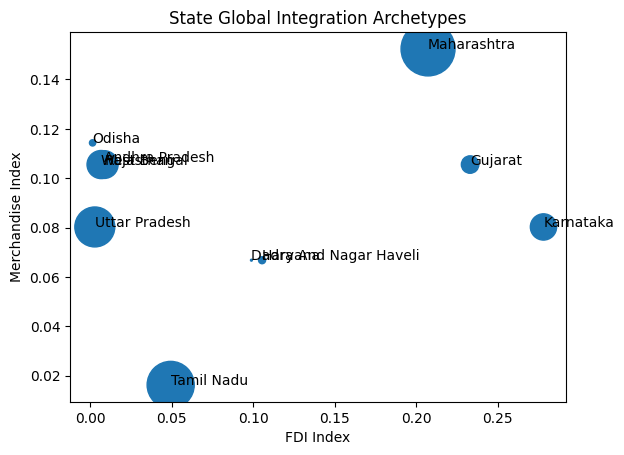

In [21]:
import matplotlib.pyplot as plt

plt.scatter(
    cluster_df['FDI_Index'],
    cluster_df['Merch_Index'],
    s=cluster_df['Tourism_Index']*5000
)

plt.xlabel("FDI Index")
plt.ylabel("Merchandise Index")
plt.title("State Global Integration Archetypes")

for i, txt in enumerate(cluster_df['State']):
    plt.annotate(txt, (cluster_df['FDI_Index'][i], cluster_df['Merch_Index'][i]))

plt.show()